# Final Results Analysis

This notebook combines the saved experiment outputs from `outputs/metrics` and `outputs/predictions` into one place for final analysis and plotting.

It is designed to work after running:

```bash
python3 src/run_pipeline.py
python3 analysis/visualize_results.py
```


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent

OUTPUTS_DIR = ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
FIGURES_DIR = OUTPUTS_DIR / "figures"

print("Root:", ROOT)
print("Metrics dir:", METRICS_DIR)
print("Predictions dir:", PREDICTIONS_DIR)
print("Figures dir:", FIGURES_DIR)


Root: /Users/syy/Desktop/organism-ml-mapping
Metrics dir: /Users/syy/Desktop/organism-ml-mapping/outputs/metrics
Predictions dir: /Users/syy/Desktop/organism-ml-mapping/outputs/predictions
Figures dir: /Users/syy/Desktop/organism-ml-mapping/outputs/figures


## Load Metrics

The pipeline writes one metrics CSV per method/input variant, plus summary tables.

In [10]:
def load_all_metrics(metrics_dir: Path) -> pd.DataFrame:
    summary_path = metrics_dir / "all_metrics_summary.csv"
    if summary_path.exists():
        return pd.read_csv(summary_path)

    metric_files = [
        p for p in sorted(metrics_dir.glob("*.csv"))
        if p.name not in {
            "accuracy_comparison_table.csv",
            "macro_f1_comparison_table.csv",
            "all_metrics_with_retrieval.csv",
            "ml_metrics_summary.csv",
        }
    ]
    frames = [pd.read_csv(p) for p in metric_files]
    if not frames:
        raise FileNotFoundError("No metrics CSV files found in outputs/metrics")
    return pd.concat(frames, ignore_index=True)


metrics = load_all_metrics(METRICS_DIR)
metrics = metrics.sort_values(["split", "target", "accuracy"], ascending=[True, True, False]).reset_index(drop=True)
metrics


,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,closed_world_exact_lookup,code_only,test_clean,Bacteria Gram Stain,1.000000,1.000000,1.000000
1,closed_world_exact_lookup,name_only,test_clean,Bacteria Gram Stain,1.000000,1.000000,1.000000
2,closed_world_exact_lookup,code_plus_name,test_clean,Bacteria Gram Stain,1.000000,1.000000,1.000000
3,closed_world_normalized_lookup,code_only,test_clean,Bacteria Gram Stain,1.000000,1.000000,1.000000
4,closed_world_normalized_lookup,name_only,test_clean,Bacteria Gram Stain,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
373,random_forest,name_only,val_clean,Reported Name,0.703448,0.413142,0.676267
374,logreg,name_only,val_clean,Reported Name,0.586207,0.357968,0.491365
375,logreg,code_plus_name,val_clean,Reported Name,0.579310,0.326949,0.476978
376,logreg,code_only,val_clean,Reported Name,0.524138,0.276443,0.414754


In [11]:
metrics_test = metrics[metrics["split"].isin(["test_clean", "test_noisy"])].copy()

print("All metric rows:", len(metrics))
print("Test metric rows:", len(metrics_test))
print("Models:", metrics_test["model_type"].nunique())
print("Input variants:", sorted(metrics_test["input_variant"].unique()))
print("Splits:", sorted(metrics_test["split"].unique()))
print("Targets:", sorted(metrics_test["target"].unique()))


All metric rows: 378
Test metric rows: 252
Models: 14
Input variants: ['code_only', 'code_plus_name', 'name_only']
Splits: ['test_clean', 'test_noisy']
Targets: ['Bacteria Gram Stain', 'CLSI Breakpoint Group', 'Reported Name']


## Helper Functions

In [13]:
MODEL_LABELS = {
    "closed_world_exact_lookup": "CW Exact Lookup",
    "closed_world_normalized_lookup": "CW Norm Lookup",
    "closed_world_retrieval_top1": "CW Retrieval Top-1",
    "closed_world_retrieval_top3": "CW Retrieval Top-3",
    "closed_world_lsa_retrieval_top1": "CW LSA Top-1",
    "closed_world_lsa_retrieval_top3": "CW LSA Top-3",
    "generalization_exact_lookup": "Gen Exact Lookup",
    "generalization_normalized_lookup": "Gen Norm Lookup",
    "generalization_retrieval_top1": "Gen Retrieval Top-1",
    "generalization_retrieval_top3": "Gen Retrieval Top-3",
    "generalization_lsa_retrieval_top1": "Gen LSA Top-1",
    "generalization_lsa_retrieval_top3": "Gen LSA Top-3",
    "logreg": "Logistic Regression",
    "random_forest": "Random Forest",
}


def ensure_plot_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "model_label" not in out.columns:
        out["model_label"] = out["model_type"].map(MODEL_LABELS).fillna(out["model_type"])
    if "setting" not in out.columns:
        out["setting"] = np.where(out["model_type"].str.startswith("generalization"), "generalization", "closed_world_or_ml")
        out.loc[out["model_type"].str.startswith("closed_world"), "setting"] = "closed_world"
        out.loc[out["model_type"].isin(["logreg", "random_forest"]), "setting"] = "ml"
    return out


def top_models_table(df: pd.DataFrame, split: str, target: str, metric: str = "accuracy", n: int = 10) -> pd.DataFrame:
    cols = ["model_label", "model_type", "input_variant", "split", "target", "accuracy", "macro_f1", "weighted_f1"]
    sub = ensure_plot_columns(df)
    sub = sub[(sub["split"] == split) & (sub["target"] == target)].copy()
    return sub.sort_values(metric, ascending=False)[cols].head(n).reset_index(drop=True)


def add_setting_column(df: pd.DataFrame) -> pd.DataFrame:
    return ensure_plot_columns(df)


def format_axis(ax, xlabel: str | None = None, ylabel: str | None = None, rotation: int = 35) -> None:
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")


def prediction_path(model_type: str, input_variant: str, split: str) -> Path:
    return PREDICTIONS_DIR / f"{model_type}_{input_variant}_{split}_predictions.csv"


def load_predictions(model_type: str, input_variant: str, split: str) -> pd.DataFrame:
    path = prediction_path(model_type, input_variant, split)
    if not path.exists():
        raise FileNotFoundError(f"Missing predictions file: {path}")
    return pd.read_csv(path)


def prediction_col(target: str) -> str:
    return f"pred_{target.replace(' ', '_')}"


metrics_labeled = add_setting_column(metrics)
metrics = metrics_labeled.copy()
metrics_test = ensure_plot_columns(metrics_test)
metrics_labeled.head()


,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1,model_label,setting
0,closed_world_exact_lookup,code_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0,CW Exact Lookup,closed_world
1,closed_world_exact_lookup,name_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0,CW Exact Lookup,closed_world
2,closed_world_exact_lookup,code_plus_name,test_clean,Bacteria Gram Stain,1.0,1.0,1.0,CW Exact Lookup,closed_world
3,closed_world_normalized_lookup,code_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0,CW Norm Lookup,closed_world
4,closed_world_normalized_lookup,name_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0,CW Norm Lookup,closed_world


## Top Models By Split And Target

In [14]:
for split in sorted(metrics_test["split"].unique()):
    print("\n===", split, "===")
    for target in sorted(metrics_test["target"].unique()):
        print("\n--", target, "--")
        display(top_models_table(metrics_test, split=split, target=target, metric="accuracy", n=8))



=== test_clean ===

-- Bacteria Gram Stain --


,model_label,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,CW Exact Lookup,closed_world_exact_lookup,code_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
1,CW Retrieval Top-1,closed_world_retrieval_top1,name_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
2,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_plus_name,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
3,CW Exact Lookup,closed_world_exact_lookup,name_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
4,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
5,CW Retrieval Top-1,closed_world_retrieval_top1,code_plus_name,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
6,CW LSA Top-1,closed_world_lsa_retrieval_top1,name_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0
7,CW Retrieval Top-1,closed_world_retrieval_top1,code_only,test_clean,Bacteria Gram Stain,1.0,1.0,1.0



-- CLSI Breakpoint Group --


,model_label,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,CW Exact Lookup,closed_world_exact_lookup,code_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
1,CW Retrieval Top-1,closed_world_retrieval_top1,name_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
2,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_plus_name,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
3,CW Exact Lookup,closed_world_exact_lookup,name_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
4,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
5,CW Retrieval Top-1,closed_world_retrieval_top1,code_plus_name,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
6,CW LSA Top-1,closed_world_lsa_retrieval_top1,name_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0
7,CW Retrieval Top-1,closed_world_retrieval_top1,code_only,test_clean,CLSI Breakpoint Group,1.0,1.0,1.0



-- Reported Name --


...

,model_label,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,CW Retrieval Top-1,closed_world_retrieval_top1,code_plus_name,test_noisy,Bacteria Gram Stain,1.000000,1.000000,1.000000
1,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_plus_name,test_noisy,Bacteria Gram Stain,1.000000,1.000000,1.000000
2,CW Retrieval Top-1,closed_world_retrieval_top1,code_only,test_noisy,Bacteria Gram Stain,0.993103,0.993092,0.993101
3,CW Retrieval Top-1,closed_world_retrieval_top1,name_only,test_noisy,Bacteria Gram Stain,0.986207,0.986190,0.986207
4,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_only,test_noisy,Bacteria Gram Stain,0.986207,0.986190,0.986207
5,CW LSA Top-1,closed_world_lsa_retrieval_top1,name_only,test_noisy,Bacteria Gram Stain,0.979310,0.979295,0.979314
6,CW LSA Top-3,closed_world_lsa_retrieval_top3,code_plus_name,test_noisy,Bacteria Gram Stain,0.965517,0.965511,0.965527
7,CW Retrieval Top-3,closed_world_retrieval_top3,code_plus_name,test_noisy,Bacteria Gram Stain,0.958621,0.958603,0.958633



-- CLSI Breakpoint Group --


,model_label,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,CW Retrieval Top-1,closed_world_retrieval_top1,code_plus_name,test_noisy,CLSI Breakpoint Group,1.000000,1.000000,1.000000
1,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_plus_name,test_noisy,CLSI Breakpoint Group,1.000000,1.000000,1.000000
2,CW Retrieval Top-1,closed_world_retrieval_top1,code_only,test_noisy,CLSI Breakpoint Group,0.986207,0.990128,0.986742
3,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_only,test_noisy,CLSI Breakpoint Group,0.965517,0.980789,0.964907
4,CW Retrieval Top-1,closed_world_retrieval_top1,name_only,test_noisy,CLSI Breakpoint Group,0.958621,0.983674,0.958212
5,CW Retrieval Top-3,closed_world_retrieval_top3,code_plus_name,test_noisy,CLSI Breakpoint Group,0.944828,0.880494,0.939355
6,CW LSA Top-1,closed_world_lsa_retrieval_top1,name_only,test_noisy,CLSI Breakpoint Group,0.944828,0.965861,0.945335
7,CW LSA Top-3,closed_world_lsa_retrieval_top3,code_plus_name,test_noisy,CLSI Breakpoint Group,0.944828,0.883505,0.941334



-- Reported Name --


,model_label,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1
0,CW Retrieval Top-1,closed_world_retrieval_top1,code_plus_name,test_noisy,Reported Name,1.000000,1.000000,1.000000
1,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_plus_name,test_noisy,Reported Name,1.000000,1.000000,1.000000
2,CW Retrieval Top-3,closed_world_retrieval_top3,code_plus_name,test_noisy,Reported Name,0.958621,0.937998,0.954220
3,CW Retrieval Top-1,closed_world_retrieval_top1,code_only,test_noisy,Reported Name,0.944828,0.875214,0.949732
4,CW Retrieval Top-1,closed_world_retrieval_top1,name_only,test_noisy,Reported Name,0.937931,0.920888,0.930757
5,CW LSA Top-3,closed_world_lsa_retrieval_top3,code_plus_name,test_noisy,Reported Name,0.937931,0.887571,0.931232
6,CW LSA Top-1,closed_world_lsa_retrieval_top1,code_only,test_noisy,Reported Name,0.924138,0.859502,0.922027
7,CW LSA Top-1,closed_world_lsa_retrieval_top1,name_only,test_noisy,Reported Name,0.910345,0.878343,0.906127


## Pivoted Summary Tables

In [15]:
accuracy_table = metrics_test.pivot_table(
    index=["model_type", "input_variant", "split"],
    columns="target",
    values="accuracy",
).sort_index()

macro_f1_table = metrics_test.pivot_table(
    index=["model_type", "input_variant", "split"],
    columns="target",
    values="macro_f1",
).sort_index()

display(accuracy_table.head(20))
display(macro_f1_table.head(20))


target                                                     Bacteria Gram Stain  CLSI Breakpoint Group  Reported Name
model_type                      input_variant  split                                                                
closed_world_exact_lookup       code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.420690               0.420690       0.420690
                                code_plus_name test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.082759               0.082759       0.082759
                                name_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.213793               0.213793       0.213793
closed_world_lsa_retrieval_top1 code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.986207               0.965517       0.924138
                                code_plus_name test_clean             1.000000               1.000000       1.000000
                                               test_noisy             1.000000               1.000000       1.000000
                                name_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.979310               0.944828       0.910345
closed_world_lsa_retrieval_top3 code_only      test_clean             0.931034               0.889655       0.889655
                                               test_noisy             0.924138               0.868966       0.827586
                                code_plus_name test_clean             0.986207               0.972414       0.958621
                                               test_noisy             0.965517               0.944828       0.937931
                                name_only      test_clean             0.986207               0.958621       0.944828
                                               test_noisy             0.931034               0.882759       0.834483
closed_world_normalized_lookup  code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.696552               0.696552       0.696552

target                                                     Bacteria Gram Stain  CLSI Breakpoint Group  Reported Name
model_type                      input_variant  split                                                                
closed_world_exact_lookup       code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.395097               0.577991       0.434609
                                code_plus_name test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.101355               0.184302       0.107143
                                name_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.233450               0.323548       0.255861
closed_world_lsa_retrieval_top1 code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.986190               0.980789       0.859502
                                code_plus_name test_clean             1.000000               1.000000       1.000000
                                               test_noisy             1.000000               1.000000       1.000000
                                name_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.979295               0.965861       0.878343
closed_world_lsa_retrieval_top3 code_only      test_clean             0.931005               0.853597       0.831667
                                               test_noisy             0.924123               0.842983       0.718739
                                code_plus_name test_clean             0.986190               0.940320       0.925156
                                               test_noisy             0.965511               0.883505       0.887571
                                name_only      test_clean             0.986190               0.891397       0.905345
                                               test_noisy             0.930952               0.830501       0.778269
closed_world_normalized_lookup  code_only      test_clean             1.000000               1.000000       1.000000
                                               test_noisy             0.547658               0.737185       0.698712

## Core Comparison Plots

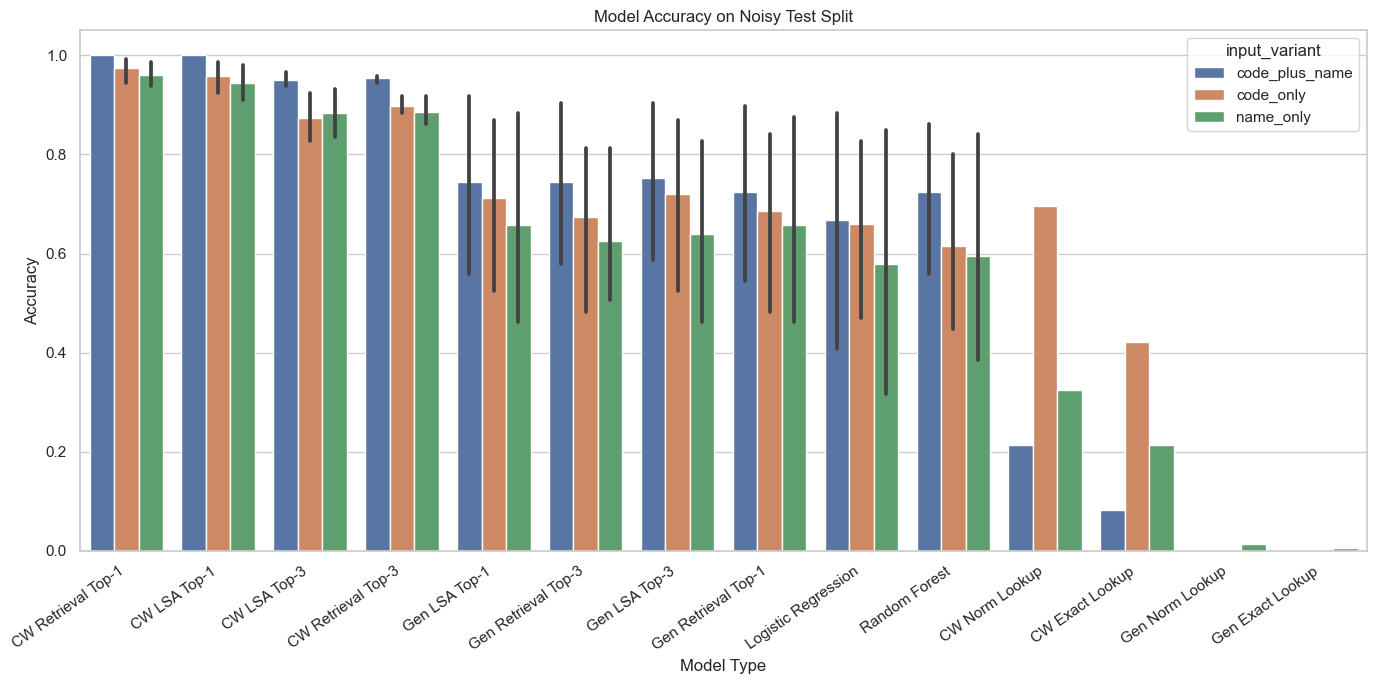

In [16]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=metrics_test[metrics_test["split"] == "test_noisy"],
    x="model_label",
    y="accuracy",
    hue="input_variant",
)
ax = plt.gca()
ax.set_title("Model Accuracy on Noisy Test Split")
format_axis(ax, xlabel="Model Type", ylabel="Accuracy")
plt.tight_layout()
plt.show()


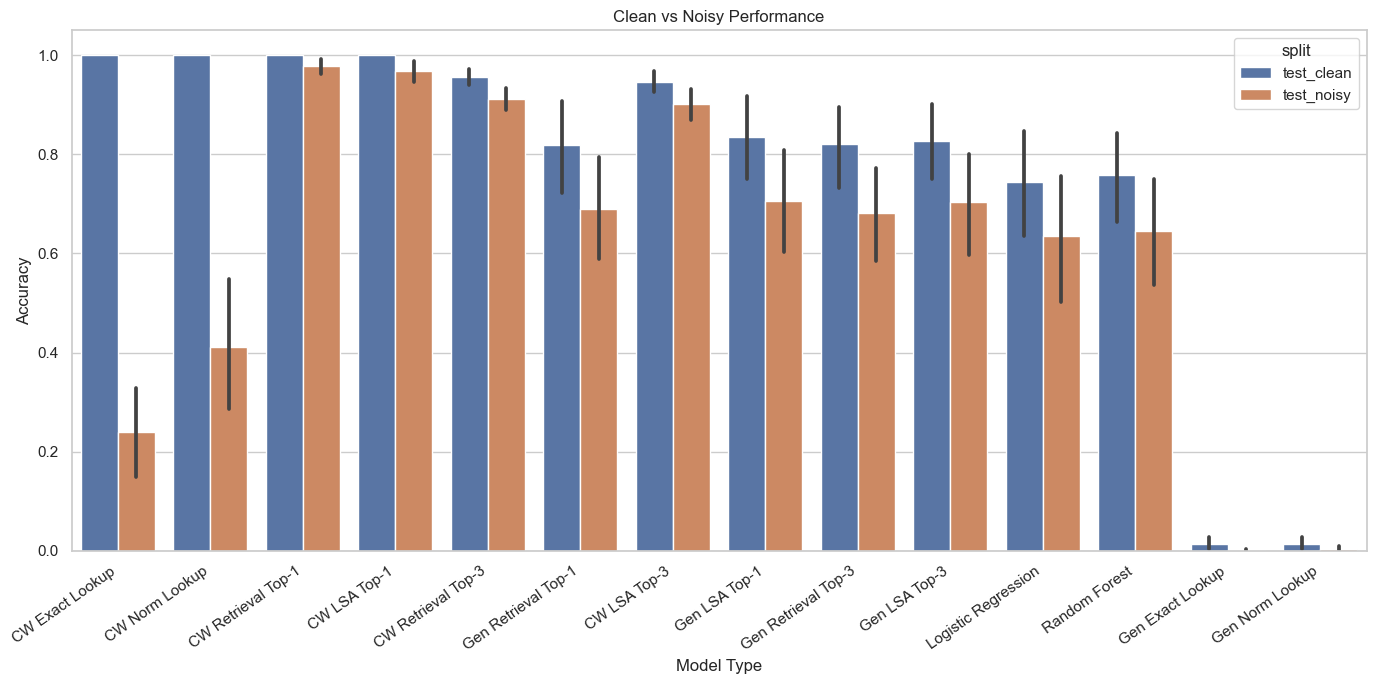

In [17]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=metrics_test,
    x="model_label",
    y="accuracy",
    hue="split",
)
ax = plt.gca()
ax.set_title("Clean vs Noisy Performance")
format_axis(ax, xlabel="Model Type", ylabel="Accuracy")
plt.tight_layout()
plt.show()


/Users/syy/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


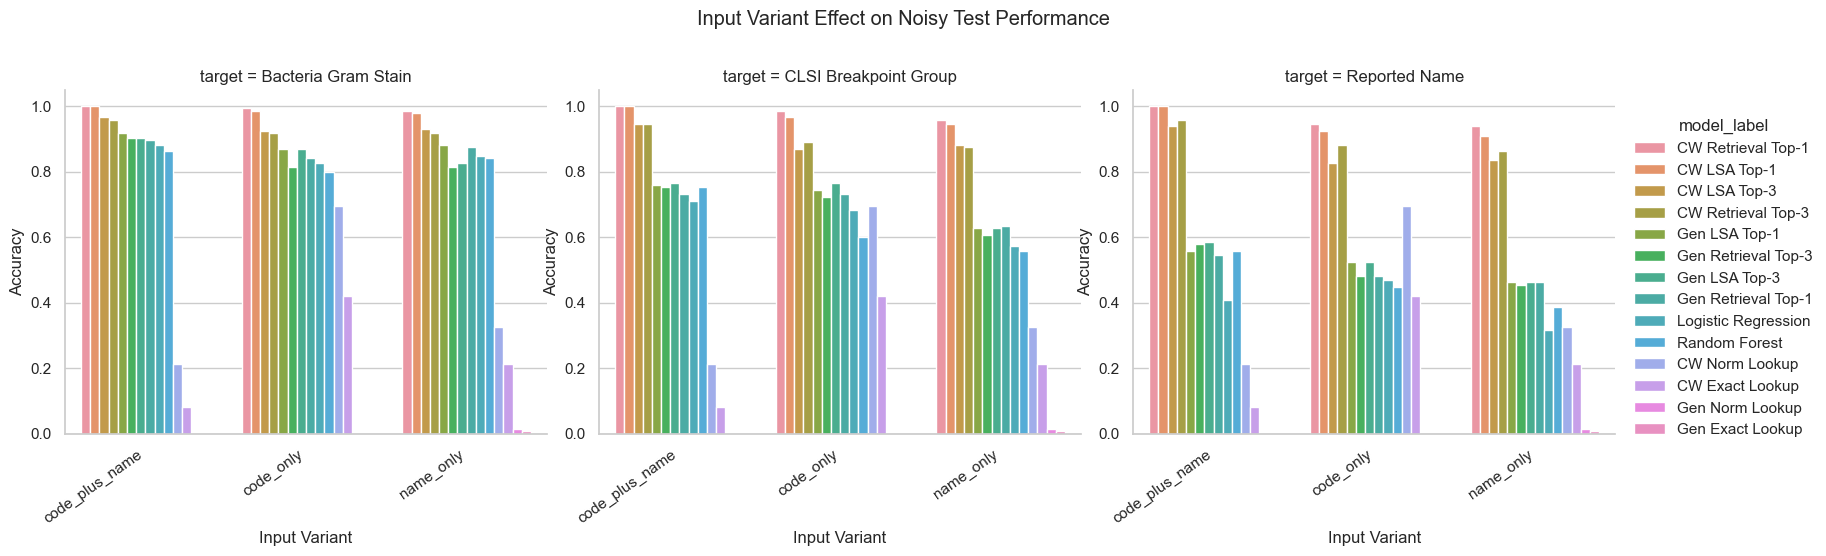

In [18]:
g = sns.catplot(
    data=metrics_test[metrics_test["split"] == "test_noisy"],
    x="input_variant",
    y="accuracy",
    hue="model_label",
    col="target",
    kind="bar",
    height=5,
    aspect=1.1,
    sharey=False,
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Input Variant Effect on Noisy Test Performance")
for ax in g.axes.flat:
    format_axis(ax, xlabel="Input Variant", ylabel="Accuracy", rotation=35)
plt.show()


## Robustness Drop From Clean To Noisy

split,model_type,model_label,input_variant,target,test_clean,test_noisy,robustness_drop
3,closed_world_exact_lookup,CW Exact Lookup,code_plus_name,Bacteria Gram Stain,1.000000,0.082759,0.917241
4,closed_world_exact_lookup,CW Exact Lookup,code_plus_name,CLSI Breakpoint Group,1.000000,0.082759,0.917241
5,closed_world_exact_lookup,CW Exact Lookup,code_plus_name,Reported Name,1.000000,0.082759,0.917241
30,closed_world_normalized_lookup,CW Norm Lookup,code_plus_name,Bacteria Gram Stain,1.000000,0.213793,0.786207
6,closed_world_exact_lookup,CW Exact Lookup,name_only,Bacteria Gram Stain,1.000000,0.213793,0.786207
7,closed_world_exact_lookup,CW Exact Lookup,name_only,CLSI Breakpoint Group,1.000000,0.213793,0.786207
8,closed_world_exact_lookup,CW Exact Lookup,name_only,Reported Name,1.000000,0.213793,0.786207
32,closed_world_normalized_lookup,CW Norm Lookup,code_plus_name,Reported Name,1.000000,0.213793,0.786207
31,closed_world_normalized_lookup,CW Norm Lookup,code_plus_name,CLSI Breakpoint Group,1.000000,0.213793,0.786207
35,closed_world_normalized_lookup,CW Norm Lookup,name_only,Reported Name,1.000000,0.324138,0.675862


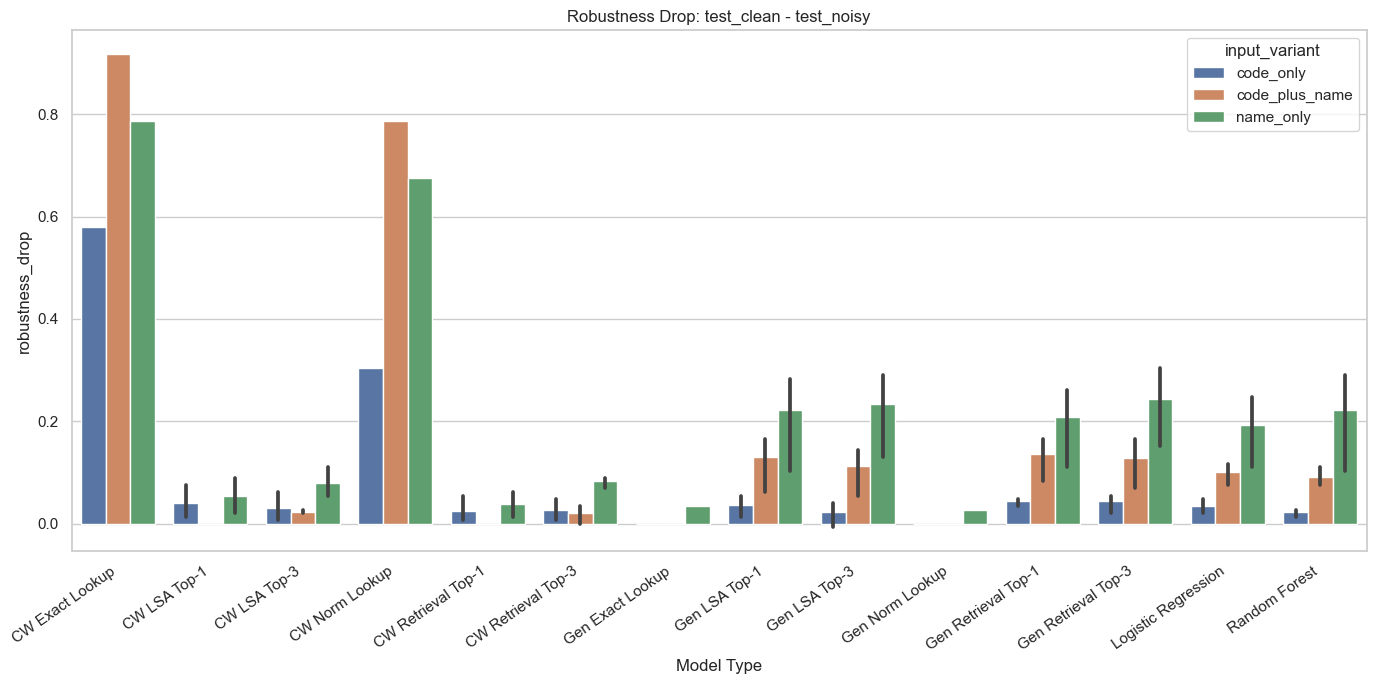

In [19]:
pivot = metrics_test.pivot_table(
    index=["model_type", "model_label", "input_variant", "target"],
    columns="split",
    values="accuracy",
).reset_index()

if {"test_clean", "test_noisy"}.issubset(set(pivot.columns)):
    pivot["robustness_drop"] = pivot["test_clean"] - pivot["test_noisy"]
    display(pivot.sort_values("robustness_drop", ascending=False).head(20))

    plt.figure(figsize=(14, 7))
    sns.barplot(
        data=pivot,
        x="model_label",
        y="robustness_drop",
        hue="input_variant",
    )
    ax = plt.gca()
    ax.set_title("Robustness Drop: test_clean - test_noisy")
    format_axis(ax, xlabel="Model Type", ylabel="robustness_drop")
    plt.tight_layout()
    plt.show()


## Compare Closed-World vs Generalization

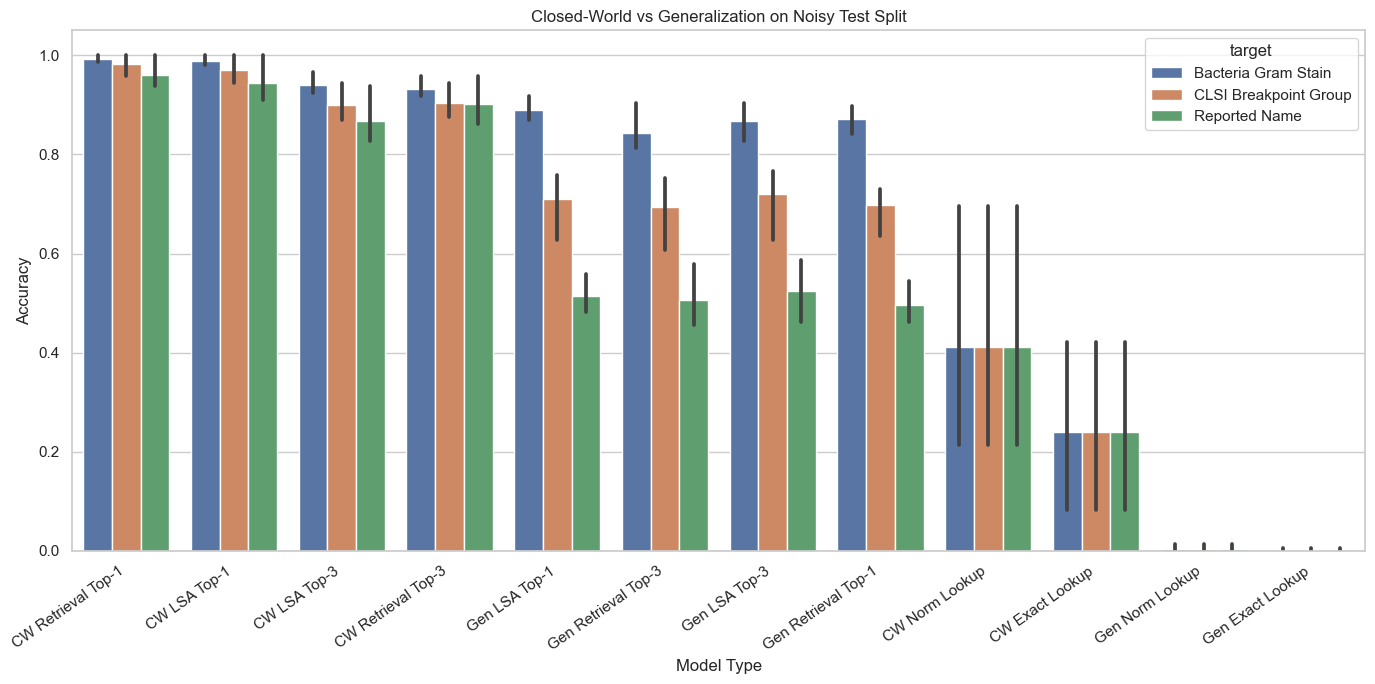

In [20]:
retrieval_like = metrics_labeled[
    metrics_labeled["model_type"].str.startswith("closed_world") |
    metrics_labeled["model_type"].str.startswith("generalization")
].copy()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=retrieval_like[retrieval_like["split"] == "test_noisy"],
    x="model_label",
    y="accuracy",
    hue="target",
)
ax = plt.gca()
ax.set_title("Closed-World vs Generalization on Noisy Test Split")
format_axis(ax, xlabel="Model Type", ylabel="Accuracy")
plt.tight_layout()
plt.show()


## Focused Comparison: Best Noisy-Test Result Per Target

In [21]:
best_noisy = (
    metrics_test[metrics_test["split"] == "test_noisy"]
    .sort_values(["target", "accuracy"], ascending=[True, False])
    .groupby("target")
    .head(10)
)
display(best_noisy)


,model_type,input_variant,split,target,accuracy,macro_f1,weighted_f1,model_label,setting
126,closed_world_retrieval_top1,code_plus_name,test_noisy,Bacteria Gram Stain,1.000000,1.000000,1.000000,CW Retrieval Top-1,closed_world
127,closed_world_lsa_retrieval_top1,code_plus_name,test_noisy,Bacteria Gram Stain,1.000000,1.000000,1.000000,CW LSA Top-1,closed_world
128,closed_world_retrieval_top1,code_only,test_noisy,Bacteria Gram Stain,0.993103,0.993092,0.993101,CW Retrieval Top-1,closed_world
129,closed_world_retrieval_top1,name_only,test_noisy,Bacteria Gram Stain,0.986207,0.986190,0.986207,CW Retrieval Top-1,closed_world
130,closed_world_lsa_retrieval_top1,code_only,test_noisy,Bacteria Gram Stain,0.986207,0.986190,0.986207,CW LSA Top-1,closed_world
131,closed_world_lsa_retrieval_top1,name_only,test_noisy,Bacteria Gram Stain,0.979310,0.979295,0.979314,CW LSA Top-1,closed_world
132,closed_world_lsa_retrieval_top3,code_plus_name,test_noisy,Bacteria Gram Stain,0.965517,0.965511,0.965527,CW LSA Top-3,closed_world
133,closed_world_retrieval_top3,code_plus_name,test_noisy,Bacteria Gram Stain,0.958621,0.958603,0.958633,CW Retrieval Top-3,closed_world
134,closed_world_lsa_retrieval_top3,name_only,test_noisy,Bacteria Gram Stain,0.931034,0.930952,0.931034,CW LSA Top-3,closed_world
135,closed_world_lsa_retrieval_top3,code_only,test_noisy,Bacteria Gram Stain,0.924138,0.924123,0.924160,CW LSA Top-3,closed_world


## Prediction Error Drilldown

Pick any saved prediction file by setting the three variables below.

In [22]:
model_type = "generalization_retrieval_top3"
input_variant = "code_plus_name"
split = "test_noisy"

pred_df = load_predictions(model_type, input_variant, split)
pred_df.head()


,Species Code,Species Full Name,Reported Name,CLSI Breakpoint Group,Bacteria Gram Stain,row_id,input_code,input_name,input_both,input_code_lower,input_name_lower,input_both_lower,is_noisy_augmented,pred_Reported_Name,pred_CLSI_Breakpoint_Group,pred_Bacteria_Gram_Stain
0,mycavs,M. avium intracellulare scrofulaceum complex,Mycobacterium avium intracellulare scrofulaceu...,"Mycobacteria, Nocardia spp., and Other Aerobic...",Positive,543,species_code=mycavs,organism=M. avium intracellulare scrofulaceum ...,species_code=mycavs organism=M. avium intracel...,species_code=mycavs,organism=m. avium intracellulare scrofulaceum ...,species_code=mycavs organism=m. avium intracel...,1,Mycobacterium intracellulare,"Mycobacteria, Nocardia spp., and Other Aerobic...",Positive
1,vibmet,V. metschnikovii,Vibrio spp.,Vibrio,Negative,945,species_code=vibmet,organism=V. metschnikovii,species_code=vibmet organism=V. metschnikovii,species_code=vibmet,organism=v. metschnikovii,species_code=vibmet organism=v. metschnikovii,1,Vibrio spp.,Vibrio,Negative
2,E,species (all),Enterococcus spp.,Enterococcus,Positive,367,species_code=E,organism=species (all),species_code=E organism=species (all),species_code=e,organism=species (all),species_code=e organism=species (all),1,Streptococcus spp. Viridans Group,Streptococcus spp. Viridans Group,Negative
3,ACTSCH,A. schaalii (formerly Actinobaculum),Actinotignum schaalii,Anaerobes,Positive,43,species_code=ACTSCH,organism=A. schaalii (formerly Actinobaculum),species_code=ACTSCH organism=A. schaalii (form...,species_code=actsch,organism=a. schaalii (formerly actinobaculum),species_code=actsch organism=a. schaalii (form...,1,Actinobaculum spp.,Coryneform Bacteria,Positive
4,YERKRI,Yersinia kristensenii,Yersinia spp.,Enterobacterales,Negative,959,species_code=YERKRI,organism=Yersinia kristensenii,species_code=YERKRI organism=Yersinia kristens...,species_code=yerkri,organism=yersinia kristensenii,species_code=yerkri organism=yersinia kristens...,1,Yersinia spp.,Enterobacterales,Negative


In [23]:
for target in ["Reported Name", "CLSI Breakpoint Group", "Bacteria Gram Stain"]:
    pred_col = prediction_col(target)
    acc = (pred_df[target] == pred_df[pred_col]).mean()
    print(f"{target}: {acc:.4f}")


Reported Name: 0.5793
CLSI Breakpoint Group: 0.7517
Bacteria Gram Stain: 0.9034


In [24]:
target = "CLSI Breakpoint Group"
pred_col = prediction_col(target)
errors = pred_df.loc[pred_df[target] != pred_df[pred_col], [
    "Species Code",
    "Species Full Name",
    target,
    pred_col,
]].copy()
errors.head(20)


,Species Code,Species Full Name,CLSI Breakpoint Group,pred_CLSI_Breakpoint_Group
2,E,species (all),Enterococcus,Streptococcus spp. Viridans Group
3,ACTSCH,A. schaalii (formerly Actinobaculum),Anaerobes,Coryneform Bacteria
6,BACBRE,Brevbacillus species,Coryneform Bacteria,Bacillus
7,ppasmul,P multocida,Pasteurella,Other Non-Enterobacterales
9,bacmer,B merdae,Anaerobes,Bacillus
11,strmon,Steptobacillus moniliformis,Other Non-Enterobacterales,Bacillus
15,lismoc,Listeria monocytogenes,Listeria,Other Non-Enterobacterales
16,paespe,P species,Bacillus,Other Non-Enterobacterales
17,salana,S. anatum,Salmonella and Shigella,Anaerobes
20,pepsac,S saccharolyticus,Staphylococcus,Anaerobes


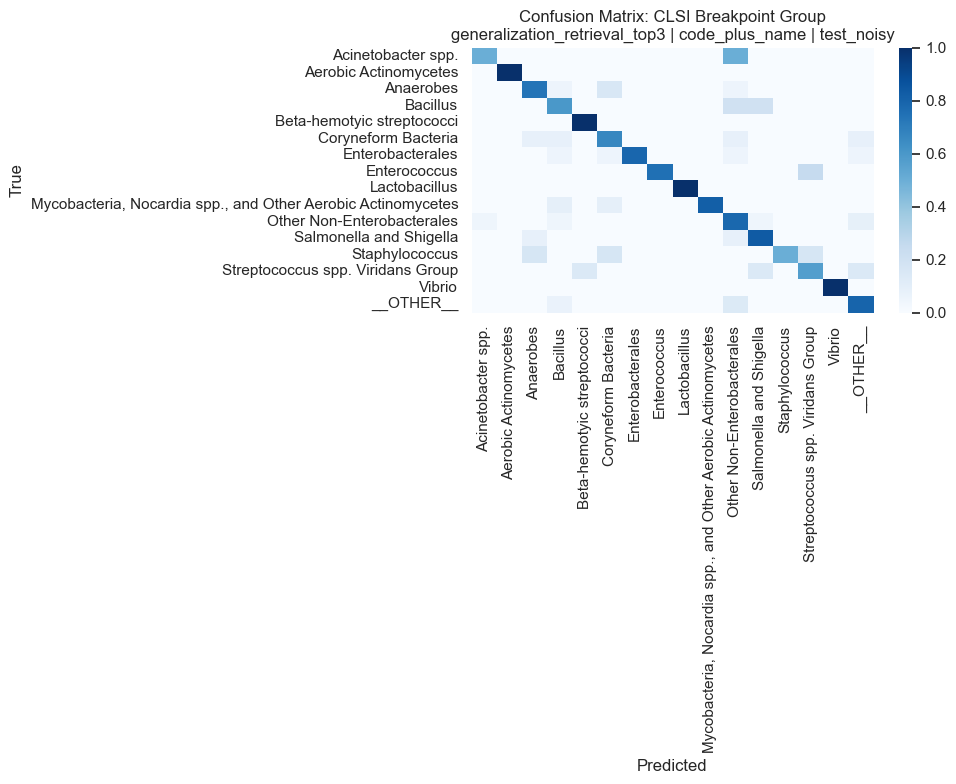

In [25]:
def plot_confusion_from_predictions(df: pd.DataFrame, target: str, max_labels: int = 15, normalize: bool = True):
    pred_col = prediction_col(target)
    truth = df[target].copy()
    pred = df[pred_col].copy()

    counts = truth.value_counts()
    keep = set(counts.head(max_labels).index)
    truth = truth.where(truth.isin(keep), "__OTHER__")
    pred = pred.where(pred.isin(keep), "__OTHER__")

    labels = sorted(set(truth.unique()) | set(pred.unique()))
    cm = confusion_matrix(truth, pred, labels=labels, normalize="true" if normalize else None)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(f"Confusion Matrix: {target}\n{model_type} | {input_variant} | {split}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


plot_confusion_from_predictions(pred_df, target="CLSI Breakpoint Group", max_labels=15, normalize=True)


## Show Saved Figures From `analysis/visualize_results.py`

In [ ]:
for name in [
    "noisy_accuracy_comparison.png",
    "clean_vs_noisy.png",
    "input_ablation.png",
    "target_breakdown.png",
    "robustness_drop.png",
]:
    path = FIGURES_DIR / name
    print(path.name, "exists:" , path.exists())
    if path.exists():
        display(Image(filename=str(path)))


## Export Curated Tables

Optional: write compact report tables for slides or a paper draft.

In [ ]:
report_dir = OUTPUTS_DIR / "report_tables"
report_dir.mkdir(parents=True, exist_ok=True)

best_test_noisy = (
    metrics_test[metrics_test["split"] == "test_noisy"]
    .sort_values(["target", "accuracy"], ascending=[True, False])
    .groupby("target")
    .head(10)
)
best_test_noisy.to_csv(report_dir / "best_test_noisy_models.csv", index=False)

pivot.to_csv(report_dir / "robustness_drop_table.csv", index=False)
accuracy_table.reset_index().to_csv(report_dir / "accuracy_pivot.csv", index=False)
macro_f1_table.reset_index().to_csv(report_dir / "macro_f1_pivot.csv", index=False)

print("Saved tables to", report_dir)
